In [1]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np
import os

In [2]:
# 处理图像数据
image_path = "/workspaces/assemblyhelper/VM/assets/test_hand_1.jpg"
im = cv2.imread(image_path)
w_h = 512
height, width, _ = im.shape
ratio = max(width, height) / w_h
new_width = int(width / ratio)
new_height = int(height / ratio)
im = cv2.resize(im, (new_width, new_height))

print(f"origin: {width},{height}")
print(f"resize: {new_width},{new_height}")
cv2.imwrite(image_path, im)

origin: 512,384
resize: 512,384


True

In [3]:
# Download the model weights to load them here
mask_generator = SamAutomaticMaskGenerator(build_sam(checkpoint="sam_vit_h_4b8939.pth"), points_per_side=32, pred_iou_thresh=0.98, crop_n_layers=0)

In [4]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [15]:
masks[0]
print(len(masks))

4


In [6]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [7]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    segmented_image_array = np.zeros_like(image_array)

#     print(f"{image_array.shape}")
#     print(f"{len(segmentation_mask)},{len(segmentation_mask[0])}")
#     print(f"{image.size}")
    
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [8]:
# Cut out all masks
image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [9]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [10]:
def retriev(elements, search_label: str) -> int:
    # process imgs
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    image_features /= image_features.norm(dim=-1, keepdim=True)

    # process labels
    label_features = []
    for label in search_label:
        preprocessed_label = torch.stack([preprocess(l).to(device) for l in label])
        label_feature = model.encode_image(preprocessed_label)
        label_feature /= label_feature.norm(dim=-1, keepdim=True)
        label_feature = torch.mean(label_feature, dim=0, keepdim=False)
        label_features.append(label_feature)
    label_features = torch.stack(label_features)

    # Calculate similar scores
    # print(f"image_shape:{image_features.shape}")
    # print(f"text_shape:{label_features.shape}")
    probs = 100. * image_features @ label_features.T
    return probs[:, :].softmax(dim=0)

In [11]:
def get_indices_of_values_above_threshold(values, threshold):
    indices = [-1] * values.shape[0]
    for i, n in enumerate(values):
        indice = torch.argmax(n)
        if n[indice] > threshold:
            indices[i] = indice  
            print(f"{indice}, {n[indice]}")
    return indices

In [12]:
label_dir = "/workspaces/assemblyhelper/VM/labels"
labels = []
cls_list = os.listdir(label_dir)

for cls in cls_list:
    label = []
    path = os.path.join(label_dir, cls)
    imgs = os.listdir(path)
    for img in imgs:
        label.append(Image.open(os.path.join(path, img)))
    labels.append(label)

0, 1.0
1, 1.0
2, 0.90185546875


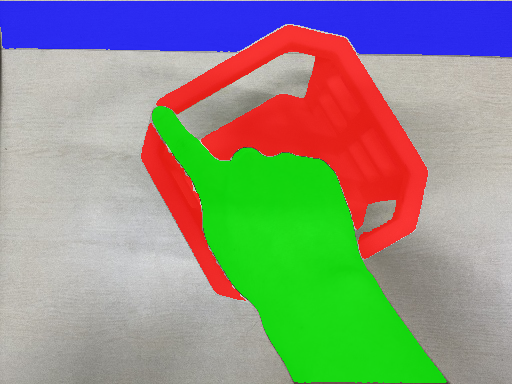

In [20]:
scores = retriev(cropped_boxes, labels)
indices = get_indices_of_values_above_threshold(scores, 0.05)

# 打开原始图像，绘制overlay
original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (0, 255, 0, 200)
overlay_color_map = [
    (255, 0, 0, 200),  # Red
    (0, 255, 0, 200),  # Green
    (0, 0, 255, 200),  # Blue
    (255, 255, 0, 200),  # Yellow
    (0, 255, 255, 200),  # Cyan
]
draw = ImageDraw.Draw(overlay_image)

for seg_idx, value in enumerate(indices):
    if value == -1:
        continue
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color_map[value])

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

In [14]:
print(cls_list)

['base', 'hand', 'ban', 'crossscrew']


In [16]:
print(indices)

[-1, tensor(0, device='cuda:0'), tensor(1, device='cuda:0'), tensor(2, device='cuda:0')]
